# Анализ данных бронирования билетов на сервисе "Яндекс Афиша"

- Автор: Севрюкова В.Ю.
- Дата: 28.04.2026г.

### Цели и задачи проекта
 В этой тетрадке используем  несколько датасетов:
 
 
 final_tickets_orders_df.csv, который включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных,
 
 
 final_tickets_events_df.csv, который содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия,
 
 
 final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год.
 
  
 Цель — выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

### Описание данных
Данные final_tickets_orders_df.csv включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:
* order_id — уникальный идентификатор заказа.
* user_id — уникальный идентификатор пользователя
* created_dt_msk — дата создания заказа (московское время)
* created_ts_msk — дата и время создания заказа (московское время)
* event_id — идентификатор мероприятия из таблицы events
* cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'
* age_limit — возрастное ограничение мероприятия.
* currency_code — валюта оплаты, например rub для российских рублей
* device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных
* revenue — выручка от заказа
* service_name — название билетного оператора
* tickets_count — количество купленных билетов
* total — общая сумма заказа


final_tickets_events_df.csv содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия:
* event_id — уникальный идентификатор мероприятия
* event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных
* event_type_description — описание типа мероприятия
* event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее
* organizers — организаторы мероприятия
* region_name — название региона
* city_name — название города
* venue_id — уникальный идентификатор площадки
* venue_name — название площадки
* venue_address — адрес площадки


final_tickets_tenge_df.csv содержит информацию о курсе тенге к российскому рублю за 2024 год (значения в рублях представлено для 100 тенге):
*  nominal — номинал (100 тенге)
*  data — дата
*  curs — курс тенге к рублю
*  cdx — обозначение валюты (kzt)

### Содержимое проекта
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Статистический анализ данных.
4. Общий вывод и рекомендации.

## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.stats.power import NormalIndPower 
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from scipy.stats import ttest_ind

In [2]:
# Позволит проверять существование указанных директорий
# актуально при одновременной работе на локальном и сетевом окружении и загружать данные из существующей директории без ошибок
import os

pth1 = '/folder_1/data.csv'
pth2 = '/folder_2/data.csv'

if os.path.exists(pth1):
    query_1 = pd.read_csv(pth1)
elif os.path.exists(pth2):
    query_1 = pd.read_csv(pth2)
else:
    print('Something is wrong')

Something is wrong


In [3]:
# Выгружаем данные в переменные 
final_tickets_orders = pd.read_csv('https://code.s3.yandex.net//datasets/final_tickets_orders_df.csv')
final_tickets_events = pd.read_csv('https://code.s3.yandex.net//datasets/final_tickets_events_df.csv')
final_tickets_tenge = pd.read_csv('https://code.s3.yandex.net//datasets/final_tickets_tenge_df.csv')

In [4]:
# Выводим первые строки датафрейма final_tickets_orders на экран
final_tickets_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [5]:
# Выводим информацию о датафрейме 
final_tickets_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [6]:
# Выводим первые строки датафрейма final_tickets_events на экран
final_tickets_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [7]:
# Выводим информацию о датафрейме 
final_tickets_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [8]:
# Выводим первые строки датафрейма final_tickets_tenge на экран
final_tickets_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [9]:
# Выводим информацию о датафрейме 
final_tickets_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB



### Промежуточный вывод

Датасет final_tickets_orders_df.csv  содержит 14 столбцов и 290848 строк.

После первичного анализа данных можно сделать следующие выводы:

Названия столбцов лучше привести к одному виду, например, snake case. Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64, float64, object. Названия столбцов отражают содержимое данных и прописаны в удобном для работы виде. Пропуски содержатся только в столбце days_since_prev. Тип данных полей created_dt_msk и created_ts_msk необходимо заменить на соответсвующий тип даты.  


Датасет final_tickets_events_df.csv содержит 11 столбцов и 22427 строк.
Названия столбцов аналогично лучше привести к одному виду, например, snake case. Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64 и object. Названия столбцов отражают содержимое данных и прописаны в удобном для работы виде. Пропуски отсутствуют.

Датасет final_tickets_tenge_df.csv содержит 4 столбца и 357 строк.
Названия столбцов привести к одному виду, например, snake case. Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64, float64, object. Названия столбцов отражают содержимое данных и прописаны в удобном для работы виде. Пропуски отсутствуют. Тип данных поля data не соотвествует верному, следует изменить.

### Подготовка единого датафрейма

In [10]:
# Выводим названия столбцов датафреймов
final_tickets_orders.columns

Index(['order_id', 'user_id', 'created_dt_msk', 'created_ts_msk', 'event_id',
       'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical',
       'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev'],
      dtype='object')

In [11]:
final_tickets_events.columns

Index(['event_id', 'event_name', 'event_type_description', 'event_type_main',
       'organizers', 'region_name', 'city_name', 'city_id', 'venue_id',
       'venue_name', 'venue_address'],
      dtype='object')

In [12]:
# Соединяем данные в единый датафрейм df
df = pd.merge(final_tickets_orders, final_tickets_events, on='event_id',how='inner')
df

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,7375078,ff684621b134cc4,2024-10-06,2024-10-06 12:32:09,12820,нет,18,rub,desktop,279.82,...,a59dafa6-f5a0-4c98-a460-5f6bb27218df,спектакль,театр,№1871,Каменевский регион,Глиногорск,213,4574,"Архив ""Туман"" Лимитед","ш. Водопроводное, д. 87 стр. 572"
290607,343390,ff684621b134cc4,2024-10-31,2024-10-31 12:27:42,357588,нет,6,rub,mobile,427.06,...,f56f3d67-4673-4fb3-b202-3f2bfd39fcf6,мюзикл,театр,№1469,Североярская область,Озёрск,2,2303,"Санкт-Петербургский дом культуры ""Сказка"" Лтд","алл. Макарова, д. 5/2"
290608,7378935,ff6bf53a0207b52,2024-10-02,2024-10-02 20:58:31,300765,нет,6,rub,mobile,224.88,...,cf71bf2b-8e5c-47e0-a0f3-c2d4910c4677,спектакль,театр,№4915,Североярская область,Озёрск,2,3850,"Творческое объединение ""Ветер"" Инкорпорэйтед","пр. Тупиковый, д. 9 стр. 8"
290609,195084,ffdadadd5de9c4b,2024-07-22,2024-07-22 13:44:54,540339,нет,6,rub,desktop,92.18,...,f17a01b7-3cd3-4cd1-919c-3459bd074886,концерт,концерты,№1742,Светополянский округ,Глиноград,54,3692,"Цирк ""Зависть"" Групп","ул. Красина, д. 64 стр. 5/7"


In [13]:
print("Процент потерянных данных при объединении таблиц:",round((len(final_tickets_orders)-len(df))/len(final_tickets_events)*100,2), "%")

Процент потерянных данных при объединении таблиц: 1.06 %


In [14]:
df.columns

Index(['order_id', 'user_id', 'created_dt_msk', 'created_ts_msk', 'event_id',
       'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical',
       'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev',
       'event_name', 'event_type_description', 'event_type_main', 'organizers',
       'region_name', 'city_name', 'city_id', 'venue_id', 'venue_name',
       'venue_address'],
      dtype='object')

In [15]:
# Создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len(temp)

290611

## 2. Предобработка данных

In [16]:
# Проверим данные на пропуски
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

In [17]:
# Подсчитываем долю строк с пропусками
df.isna().sum()/df.shape[0]

order_id                  0.000000
user_id                   0.000000
created_dt_msk            0.000000
created_ts_msk            0.000000
event_id                  0.000000
cinema_circuit            0.000000
age_limit                 0.000000
currency_code             0.000000
device_type_canonical     0.000000
revenue                   0.000000
service_name              0.000000
tickets_count             0.000000
total                     0.000000
days_since_prev           0.075403
event_name                0.000000
event_type_description    0.000000
event_type_main           0.000000
organizers                0.000000
region_name               0.000000
city_name                 0.000000
city_id                   0.000000
venue_id                  0.000000
venue_name                0.000000
venue_address             0.000000
dtype: float64

In [18]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
days_since_prev,21913,0.0754


Пропуски наблюдаются в столбцах: days_since_prev (7.5%). Процент пропусков в полях небольшой, поэтому их просто можно оставить.

Пропуски в этих столбце могут быть вызваны:


* Недостаточность данных: в некоторых случаях данные просто не были собраны или недоступны.


* Ошибки при вводе данных: человеческий фактор может привести к тому, что данные будут пропущены или некорректно введены.


* Проблемы с форматом данных: при объединении или преобразовании данных из разных источников могут возникнуть несовпадения форматов, что приведёт к появлению пропусков.


* Логические пропуски: в некоторых случаях пропуски могут быть логическим следствием структуры данных.


* Технические проблемы: ошибки при экспорте или импорте данных, сбои в системах хранения данных также могут привести к появлению пропусков.

In [19]:
# Изучим значения в ключевых категорийных столбцах

In [20]:
# Определим типы данных
df.dtypes

order_id                    int64
user_id                    object
created_dt_msk             object
created_ts_msk             object
event_id                    int64
cinema_circuit             object
age_limit                   int64
currency_code              object
device_type_canonical      object
revenue                   float64
service_name               object
tickets_count               int64
total                     float64
days_since_prev           float64
event_name                 object
event_type_description     object
event_type_main            object
organizers                 object
region_name                object
city_name                  object
city_id                     int64
venue_id                    int64
venue_name                 object
venue_address              object
dtype: object

In [21]:
# Чтобы определить, какие значения в категориальных столбцах могут обозначать пропуски данных, применим метод для подсчёта количества каждого уникального значения в столбце
df['cinema_circuit'].value_counts()

нет           289213
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

In [22]:
# Проведем нормализацию данных
df['cinema_circuit'] = df['cinema_circuit'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['cinema_circuit']

0         нет
1         нет
2         нет
3         нет
4         нет
         ... 
290606    нет
290607    нет
290608    нет
290609    нет
290610    нет
Name: cinema_circuit, Length: 290611, dtype: object

Значение "нет" (289451) может обозначать пропуски в столбце cinema_circuit.

In [23]:
df['currency_code'].value_counts()

rub    285542
kzt      5069
Name: currency_code, dtype: int64

In [24]:
df['event_name'].value_counts()

9cc55c15-4375-4129-9979-3129688ba1b4    3953
a00e1032-6463-4fdc-a105-fdbb6789b556    2519
0714435e-3b5f-4312-aa36-c3a9d8853ef4    1761
58574140-962c-49a3-af70-b773a05661a3    1749
e252d33a-2394-44b8-b11d-f0709a6f0260    1628
                                        ... 
524907cb-8288-4ac3-9ab9-a9823c1f3374       1
a58af87b-d944-4762-9af8-b711549a7579       1
72a2b157-a97e-452d-9783-fde3f638bfbc       1
a1923898-94bd-4377-a563-c99e3018cfbd       1
389ec9f5-4f74-48b5-97bd-9c44a26dcddd       1
Name: event_name, Length: 15248, dtype: int64

In [25]:
# Проведем нормализацию данных
df['event_name'] = df['event_name'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['event_name']

0         f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad
1         f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad
2         f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad
3         f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad
4         f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad
                          ...                 
290606    a59dafa6-f5a0-4c98-a460-5f6bb27218df
290607    f56f3d67-4673-4fb3-b202-3f2bfd39fcf6
290608    cf71bf2b-8e5c-47e0-a0f3-c2d4910c4677
290609    f17a01b7-3cd3-4cd1-919c-3459bd074886
290610    0fd6df8e-49e5-4337-954d-5a4606b1b899
Name: event_name, Length: 290611, dtype: object

In [26]:
df['event_type_description'].value_counts()

концерт                   112049
событие                    58605
спектакль                  50592
шоу                        13626
спорт                      12837
мюзикл                      9919
спортивное мероприятие      9074
балет                       5998
выставка                    5876
цирковое шоу                5327
фестиваль                   4273
опера                       1314
ёлка                         945
музыкальный спектакль        140
кукольный спектакль           13
экскурсия                      8
оперетта                       7
подарок                        4
снегурочка                     3
рок-мюзикл                     1
Name: event_type_description, dtype: int64

In [27]:
# Проведем нормализацию данных
df['event_type_description'] = df['event_type_description'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['event_type_description']

0         спектакль
1         спектакль
2         спектакль
3         спектакль
4         спектакль
            ...    
290606    спектакль
290607       мюзикл
290608    спектакль
290609      концерт
290610      концерт
Name: event_type_description, Length: 290611, dtype: object

In [28]:
df['event_type_main'].value_counts()

концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

In [29]:
# Проведем нормализацию данных
df['event_type_main'] = df['event_type_main'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['event_type_main']

0            театр
1            театр
2            театр
3            театр
4            театр
            ...   
290606       театр
290607       театр
290608       театр
290609    концерты
290610    концерты
Name: event_type_main, Length: 290611, dtype: object

In [30]:
df['organizers'].value_counts()

№1531    9748
№2121    4738
№4054    4362
№4549    3972
№4837    3368
         ... 
№3359       1
№3516       1
№3248       1
№3120       1
№3934       1
Name: organizers, Length: 4293, dtype: int64

In [31]:
df['region_name'].value_counts()

Каменевский регион          91058
Североярская область        44049
Широковская область         16457
Медовская область           13901
Озернинский край            10476
                            ...  
Лесноярский край               19
Крутоводский регион            18
Верхозёрский край              11
Сосноводолинская область       10
Теплоозёрский округ             7
Name: region_name, Length: 81, dtype: int64

In [32]:
# Проведем нормализацию данных
df['region_name'] = df['region_name'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['region_name']

0           каменевский_регион
1           каменевский_регион
2           каменевский_регион
3           каменевский_регион
4           каменевский_регион
                  ...         
290606      каменевский_регион
290607    североярская_область
290608    североярская_область
290609    светополянский_округ
290610    североярская_область
Name: region_name, Length: 290611, dtype: object

In [33]:
df['city_name'].value_counts()

Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
                ...  
Радужовинск         1
Байсары             1
Травино             1
Реченогор           1
Кристолесье         1
Name: city_name, Length: 352, dtype: int64

In [34]:
# Проведем нормализацию данных
df['city_name'] = df['city_name'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['city_name']

0         глиногорск
1         глиногорск
2         глиногорск
3         глиногорск
4         глиногорск
             ...    
290606    глиногорск
290607        озёрск
290608        озёрск
290609     глиноград
290610        озёрск
Name: city_name, Length: 290611, dtype: object

In [35]:
df['venue_name'].value_counts()

Студия дизайна "Платформа" Инкорпорэйтед         9910
Картинная галерея "Светлячок" Лтд                4406
Креативное пространство "Вдох" Лимитед           4257
Центр культурного наследия "Заряд" и партнеры    4099
Студия дизайна "Лестница" Лимитед                4025
                                                 ... 
Выставочный центр "Гардероб" и партнеры             1
Летний лагерь искусств "Ковчег" Групп               1
Театр на треноге "Сердце" Инк                       1
Детский дом культуры "Оркестр" Групп                1
Народный театр "Таланты" Лимитед                    1
Name: venue_name, Length: 3217, dtype: int64

In [36]:
# Проведем нормализацию данных
df['venue_name'] = df['venue_name'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['venue_name']

0                      сценический_центр_"деталь"_групп
1                      сценический_центр_"деталь"_групп
2                      сценический_центр_"деталь"_групп
3                      сценический_центр_"деталь"_групп
4                      сценический_центр_"деталь"_групп
                              ...                      
290606                            архив_"туман"_лимитед
290607    санкт-петербургский_дом_культуры_"сказка"_лтд
290608     творческое_объединение_"ветер"_инкорпорэйтед
290609                             цирк_"зависть"_групп
290610                     школа_музыки_"парадигма"_лтд
Name: venue_name, Length: 290611, dtype: object

In [37]:
df['venue_address'].value_counts()

наб. Магистральная, д. 5                9910
ул. Дальневосточная, д. 97 к. 1/4       4406
бул. Пригородный, д. 7/1                4257
ш. Пугачева, д. 9/7 к. 39               4099
наб. Школьная, д. 9/8 стр. 7/5          4025
                                        ... 
пр. Запрудный, д. 40 к. 55                 1
бул. Садовый, д. 60 стр. 50                1
алл. Социалистическая, д. 5 стр. 9/2       1
ш. Тополиное, д. 6 к. 9                    1
ш. Красногвардейское, д. 809 к. 470        1
Name: venue_address, Length: 3225, dtype: int64

In [38]:
# Проведем нормализацию данных
df['venue_address'] = df['venue_address'].astype(str).str.lower().str.strip().str.replace(' ', '_')
df['venue_address']

0         алл._машиностроителей,_д._19_стр._6
1         алл._машиностроителей,_д._19_стр._6
2         алл._машиностроителей,_д._19_стр._6
3         алл._машиностроителей,_д._19_стр._6
4         алл._машиностроителей,_д._19_стр._6
                         ...                 
290606       ш._водопроводное,_д._87_стр._572
290607                  алл._макарова,_д._5/2
290608             пр._тупиковый,_д._9_стр._8
290609            ул._красина,_д._64_стр._5/7
290610            пр._сплавный,_д._236_к._918
Name: venue_address, Length: 290611, dtype: object

In [39]:
# Изучим значения в ключевых числовых столбцах

In [40]:
df['age_limit'].describe()

count    290611.000000
mean         10.207267
std           6.518540
min           0.000000
25%           6.000000
50%          12.000000
75%          16.000000
max          18.000000
Name: age_limit, dtype: float64

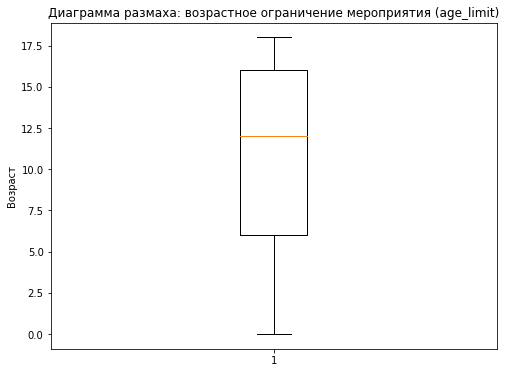

In [41]:
# Строим диаграмму размаха для столбца age_limit
plt.figure(figsize=(8, 6))
plt.boxplot(df['age_limit'])
plt.title('Диаграмма размаха: возрастное ограничение мероприятия (age_limit)')
plt.ylabel('Возраст')
plt.show()

По данным стат показателей и диаграммы размаха выбросы в столбце age_limit не определяются.

In [42]:
df['revenue'].describe()

count    290611.000000
mean        625.584360
std        1227.693064
min         -90.760000
25%         116.850000
50%         356.010000
75%         810.130000
max       81174.540000
Name: revenue, dtype: float64

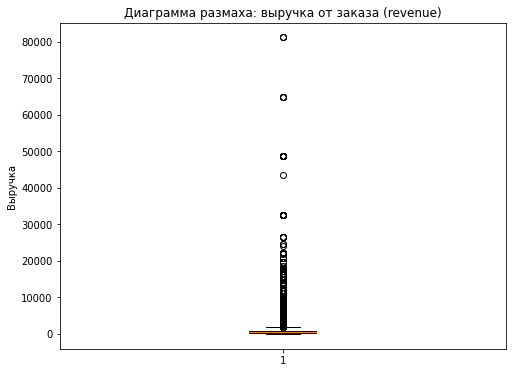

In [43]:
# Строим диаграмму размаха для столбца revenue
plt.figure(figsize=(8, 6))
plt.boxplot(df['revenue'])
plt.title('Диаграмма размаха: выручка от заказа (revenue)')
plt.ylabel('Выручка')
plt.show()

По данным стат показателей и диаграммы размаха выбросы в столбце revenue определяются, их следует убрать.

In [44]:
# Находим значение 99‑го процентиля
percentile_99 = np.percentile(df['revenue'], 99)

# Отбираем строки, где revenue ≤ 99‑го процентиля (исключаем выбросы)
df_filtered = df[df['revenue'] <= percentile_99].copy()

print(f"99‑й процентиль: {percentile_99}")
print(f"Размер исходного датафрейма: {len(df)}")
print(f"Размер отфильтрованного датафрейма: {len(df_filtered)}")

99‑й процентиль: 4003.133000000076
Размер исходного датафрейма: 290611
Размер отфильтрованного датафрейма: 287704


In [45]:
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

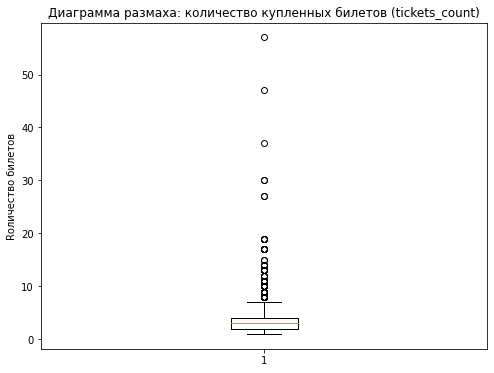

In [46]:
# Строим диаграмму размаха для столбца revenue
plt.figure(figsize=(8, 6))
plt.boxplot(df['tickets_count'])
plt.title('Диаграмма размаха: количество купленных билетов (tickets_count)')
plt.ylabel('Rоличество билетов')
plt.show()

По данным стат показателей и диаграммы размаха выбросы в столбце tickets_count определяются, их следует убрать.

In [47]:
# Находим значение 99‑го процентиля
percentile_99 = np.percentile(df['tickets_count'], 99)

# Отбираем строки, где revenue ≤ 99‑го процентиля (исключаем выбросы)
df_filtered = df[df['tickets_count'] <= percentile_99].copy()

print(f"99‑й процентиль: {percentile_99}")
print(f"Размер исходного датафрейма: {len(df)}")
print(f"Размер отфильтрованного датафрейма: {len(df_filtered)}")

99‑й процентиль: 6.0
Размер исходного датафрейма: 290611
Размер отфильтрованного датафрейма: 290423


In [48]:
# Проверяем полные дубликаты 
df_filtered.duplicated().sum()

0

Полные дубликаты отсутствуют в df_filtered.

In [49]:
# Проверим количество неявныех дубликатов 
df_filtered.duplicated(subset=['user_id','created_ts_msk','cinema_circuit', 'currency_code','device_type_canonical',
                               'service_name','event_name','event_type_description','event_type_main','organizers',
                               'region_name','city_name','venue_name','venue_address']).sum()

112

In [50]:
# Удаляем неявные дубликаты
df_filtered = df_filtered.drop_duplicates(subset=['user_id','created_ts_msk','cinema_circuit', 'currency_code','device_type_canonical',
                               'service_name','event_name','event_type_description','event_type_main','organizers',
                               'region_name','city_name','venue_name','venue_address'])

In [51]:
# Проверим количество неявныех дубликатов 
df_filtered.duplicated(subset=['user_id','created_ts_msk','cinema_circuit', 'currency_code','device_type_canonical',
                               'service_name','event_name','event_type_description','event_type_main','organizers',
                               'region_name','city_name','venue_name','venue_address']).sum()

0

In [52]:
# Проверим, сколько удалено строк датасета
a, b = len(temp), len(df_filtered)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 290611 
 Осталось строк в датасете после обработки 290311 
 Удалено строк в датасете после обработки 300 
 Процент потерь 0.1


In [53]:
# Определим типы данных
df_filtered.dtypes

order_id                    int64
user_id                    object
created_dt_msk             object
created_ts_msk             object
event_id                    int64
cinema_circuit             object
age_limit                   int64
currency_code              object
device_type_canonical      object
revenue                   float64
service_name               object
tickets_count               int64
total                     float64
days_since_prev           float64
event_name                 object
event_type_description     object
event_type_main            object
organizers                 object
region_name                object
city_name                  object
city_id                     int64
venue_id                    int64
venue_name                 object
venue_address              object
dtype: object

In [54]:
# Переведем created_dt_msk в формат даты
df_filtered['created_dt_msk'] = pd.to_datetime(df_filtered['created_dt_msk'])

In [55]:
# Переведем created_ts_msk в формат даты 
df_filtered['created_ts_msk'] = pd.to_datetime(df_filtered['created_ts_msk'])

In [56]:
# Переведем days_since_prev и tickets_count в целочисленный тип данных 
columns_to_convert = ['days_since_prev', 'tickets_count']  

for col in columns_to_convert:
    df_filtered[col] = df_filtered[col].astype('Int64')

In [57]:
# Понизим разрядность числовых данных с 64 до 32
for column in ['revenue','total']:
    df_filtered[column] = pd.to_numeric(df_filtered[column], downcast='float')

In [58]:
df_filtered.dtypes

order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                          int64
currency_code                     object
device_type_canonical             object
revenue                          float32
service_name                      object
tickets_count                      Int64
total                            float32
days_since_prev                    Int64
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                            int64
venue_id                           int64
venue_name                        object
venue_address                     object
dtype: object

In [59]:
# Выводим первые строки датафрейма final_tickets_tenge на экран
final_tickets_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [60]:
unique_values = final_tickets_tenge['cdx'].unique()
unique_values

array(['kzt'], dtype=object)

In [61]:
final_tickets_tenge.dtypes

data        object
nominal      int64
curs       float64
cdx         object
dtype: object

In [62]:
# Переведем data в формат даты 
final_tickets_tenge['data'] = pd.to_datetime(final_tickets_tenge['data'])

In [63]:
# Объединяем датафреймы по дате
merged_df = pd.merge(
    df_filtered,                    
    final_tickets_tenge,                  
    left_on='created_dt_msk',                 
    right_on='data',                          
    how='left'              # сохраняем все заказы, даже без курса
)
merged_df

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.939941,...,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-08-20,100,18.6972,kzt
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.420044,...,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-07-23,100,18.3419,kzt
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.449951,...,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-07-23,100,18.3419,kzt
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.420044,...,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-07-23,100,18.3419,kzt
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.939941,...,каменевский_регион,глиногорск,213,3972,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-07-23,100,18.3419,kzt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290306,7375078,ff684621b134cc4,2024-10-06,2024-10-06 12:32:09,12820,нет,18,rub,desktop,279.820007,...,каменевский_регион,глиногорск,213,4574,"архив_""туман""_лимитед","ш._водопроводное,_д._87_стр._572",2024-10-06,100,19.6475,kzt
290307,343390,ff684621b134cc4,2024-10-31,2024-10-31 12:27:42,357588,нет,6,rub,mobile,427.059998,...,североярская_область,озёрск,2,2303,"санкт-петербургский_дом_культуры_""сказка""_лтд","алл._макарова,_д._5/2",2024-10-31,100,19.7383,kzt
290308,7378935,ff6bf53a0207b52,2024-10-02,2024-10-02 20:58:31,300765,нет,6,rub,mobile,224.880005,...,североярская_область,озёрск,2,3850,"творческое_объединение_""ветер""_инкорпорэйтед","пр._тупиковый,_д._9_стр._8",2024-10-02,100,19.4015,kzt
290309,195084,ffdadadd5de9c4b,2024-07-22,2024-07-22 13:44:54,540339,нет,6,rub,desktop,92.180000,...,светополянский_округ,глиноград,54,3692,"цирк_""зависть""_групп","ул._красина,_д._64_стр._5/7",2024-07-22,100,18.4518,kzt


In [64]:
missing_count = merged_df['curs'].isna().sum()  # подсчёт пропусков в столбце 'curs'
print(f"Количество заказов без курса: {missing_count}")

Количество заказов без курса: 0


In [65]:
tenge_columns = ['curs', 'nominal', 'cdx']  
missing_all_count = merged_df[merged_df[tenge_columns].isna().all(axis=1)].shape[0]
print(f"Заказа без каких‑либо данных из tenge_df: {missing_all_count}")

Заказа без каких‑либо данных из tenge_df: 0


In [66]:
# Создаём новый столбец revenue_rub
merged_df['revenue_rub'] = (merged_df['revenue'] * merged_df['curs']) / 100
merged_df['revenue_rub']

0         284.560155
1         348.939982
2         209.363609
3         348.939982
4         279.152702
             ...    
290306     54.977636
290307     84.294383
290308     43.630094
290309     17.008869
290310    336.108906
Name: revenue_rub, Length: 290311, dtype: float64

In [67]:
# Посчитаем выручку с продажи одного билета на мероприятие
merged_df['one_ticket_revenue_rub'] = merged_df['revenue_rub'] / merged_df['tickets_count']
merged_df['one_ticket_revenue_rub']

0         71.140039
1         69.787996
2          69.78787
3         69.787996
4         69.788176
            ...    
290306    18.325879
290307    21.073596
290308    14.543365
290309    17.008869
290310    56.018151
Name: one_ticket_revenue_rub, Length: 290311, dtype: Float64

In [68]:
# Выделим месяц оформления заказа в отдельный столбец
merged_df['month'] = merged_df['created_dt_msk'].dt.month
merged_df['month']

0          8
1          7
2          7
3          7
4          7
          ..
290306    10
290307    10
290308    10
290309     7
290310    10
Name: month, Length: 290311, dtype: int64

In [69]:
print(merged_df[['order_id', 'created_dt_msk', 'month']].head(5))

   order_id created_dt_msk  month
0   4359165     2024-08-20      8
1   7431164     2024-07-23      7
2   7431106     2024-07-23      7
3   7431135     2024-07-23      7
4   7431048     2024-07-23      7


In [70]:
# Создаим столбец с информацией о сезонности

def get_season_by_quarter(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

merged_df['season'] = merged_df['month'].apply(get_season_by_quarter)
merged_df['season']

0          лето
1          лето
2          лето
3          лето
4          лето
          ...  
290306    осень
290307    осень
290308    осень
290309     лето
290310    осень
Name: season, Length: 290311, dtype: object

In [71]:
# Проверим, сколько удалено строк датасета
a, b = len(temp), len(merged_df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 290611 
 Осталось строк в датасете после обработки 290311 
 Удалено строк в датасете после обработки 300 
 Процент потерь 0.1


Таким образом, после обработки данных из 290 611 строк датасета у нас осталось 290 311 (0.1% потерь).
Были изучены пропуски в данных ,они наблюдались в столбце days_since_prev (7.5%). Процент пропуска в поле небольшой, поэтому его просто можно оставить.
Так же произвели нормализацию данных в столбцах: cinema_circuit, event_name, event_type_description,event_type_main, region_name, city_name, venue_name, venue_address; данные проверили на явные и неявные дубликаты, и удалили.
По данным стат показателей и диаграммы размаха, были обнаружены и удалены выбросы в столбцах: revenue, tickets_count. Изменили тип данных created_dt_msk, created_ts_msk,data, понизили разрядность - days_since_prev, tickets_count, revenue, total, а так же создали столбцы revenue_rub (выручка с заказа в рублях), one_ticket_revenue_rub (выручка с продажи одного билета на мероприятие в рублях), month (месяц оформления заказа), season (столбец с информацией о сезонности).

## 3. Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

In [72]:
merged_df.columns

Index(['order_id', 'user_id', 'created_dt_msk', 'created_ts_msk', 'event_id',
       'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical',
       'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev',
       'event_name', 'event_type_description', 'event_type_main', 'organizers',
       'region_name', 'city_name', 'city_id', 'venue_id', 'venue_name',
       'venue_address', 'data', 'nominal', 'curs', 'cdx', 'revenue_rub',
       'one_ticket_revenue_rub', 'month', 'season'],
      dtype='object')

Выручка по типам мероприятий:


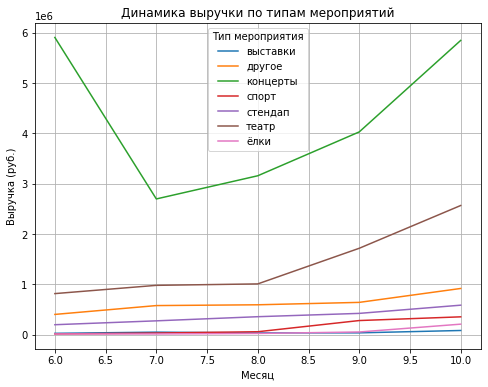

In [73]:
# Проанализируем размер выручки в разрезе типов мероприятий
# Группируем по типу мероприятия и месяцу, считаем суммарную выручку
revenue_by_event_type = merged_df.groupby([
    'month', 
    'event_type_main'    
])['revenue_rub'].sum().unstack(fill_value=0)  # fill_value=0 — заполняем пропуски нулями

print("Выручка по типам мероприятий:")
revenue_by_event_type

# Визуализация
revenue_by_event_type.plot(kind='line', figsize=(8, 6))
plt.title('Динамика выручки по типам мероприятий')
plt.xlabel('Месяц')
plt.ylabel('Выручка (руб.)')
plt.legend(title='Тип мероприятия')
plt.grid(True)
plt.show()

Размер выручки от мероприятий: выставки  (0.3 % - 0.06 %), спорт (0.2 % - 1 %), стендап (2.6 % - 7 %), театр (11 % - 19.3 %) и елки (0.2 % - 0.4 %) - с июня по август был стабилен, с августа по октябрь начал увеличиваться составлял у выставок (0.06 - 0.08 %), спорта (0.2 % - 3.3 %),театра (19.3 % - 24.3) и елок (0.4 % - 2 %), а у стендапа (7 % - 5.5 %) - незначительно сократился.
Размер выручки концертов с июня по июль сокращался (80 % - 55.4%), с июля по сентябрь происходит постепенный рост (58.5% - 56.2%).

In [74]:
# Посчитаем общую выручку по месяцам
total_revenue_by_month = merged_df.groupby('month')['revenue_rub'].sum()

# Переведем выручку по типам мероприятий в доли
revenue_shares_by_event_type = revenue_by_event_type.div(total_revenue_by_month, axis=0)

print("Доли выручки по типам мероприятий:")
print(revenue_shares_by_event_type)

Доли выручки по типам мероприятий:
event_type_main  выставки    другое  концерты     спорт   стендап     театр  \
month                                                                         
6                0.003219  0.054290  0.802504  0.001507  0.026485  0.110528   
7                0.010199  0.124881  0.584996  0.006333  0.059025  0.212156   
8                0.006180  0.113314  0.605021  0.010635  0.067913  0.192886   
9                0.004633  0.089207  0.562338  0.038774  0.058651  0.239362   
10               0.007592  0.086784  0.554299  0.033325  0.055304  0.243155   

event_type_main      ёлки  
month                      
6                0.001467  
7                0.002411  
8                0.004051  
9                0.007035  
10               0.019541  


Выручка по типам устройств:
device_type_canonical       desktop        mobile
month                                            
6                      2.247526e+06  5.115385e+06
7                      1.008602e+06  3.601299e+06
8                      9.814218e+05  4.238110e+06
9                      1.376724e+06  5.789620e+06
10                     2.259171e+06  8.294596e+06


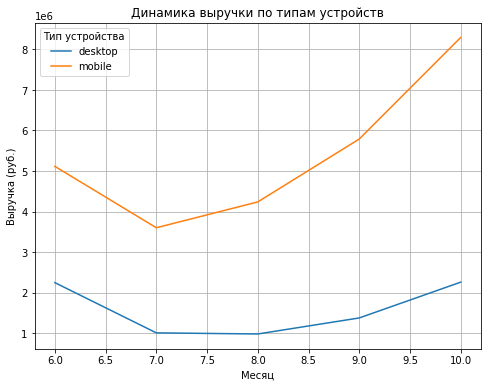

In [75]:
# Проанализируем размер выручки в разрезе типов устройств
# Группировка по устройству и месяцу
revenue_by_device = merged_df.groupby([
    'month',
    'device_type_canonical'
])['revenue_rub'].sum().unstack(fill_value=0)

print("Выручка по типам устройств:")
print(revenue_by_device)

# Визуализация
revenue_by_device.plot(kind='line', figsize=(8, 6))
plt.title('Динамика выручки по типам устройств')
plt.xlabel('Месяц')
plt.ylabel('Выручка (руб.)')
plt.legend(title='Тип устройства')
plt.grid(True)
plt.show()

Выручка по возрастным категориям:
age_limit            0             6             12            16  \
month                                                               
6          3.059392e+05  7.418286e+05  3.812461e+06  1.928185e+06   
7          4.900377e+05  8.627030e+05  1.089485e+06  1.487785e+06   
8          4.485715e+05  9.046883e+05  1.283681e+06  1.795298e+06   
9          6.600409e+05  1.348171e+06  1.936965e+06  2.289312e+06   
10         1.183056e+06  1.917045e+06  2.745253e+06  3.290276e+06   

age_limit            18  
month                    
6          5.744969e+05  
7          6.798907e+05  
8          7.872930e+05  
9          9.318553e+05  
10         1.418136e+06  


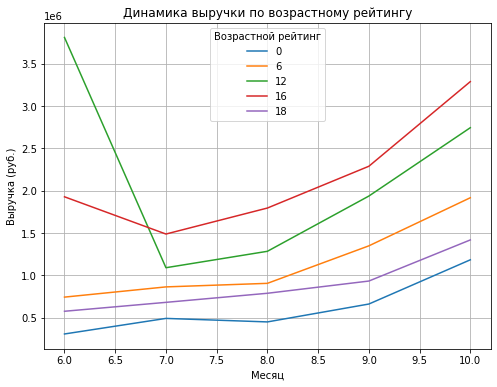

In [76]:
# Проанализируем размер выручки в разрезе возрастного рейтинга
# Группировка по возрастному рейтингу и месяцу
revenue_by_age = merged_df.groupby([
    'month',
    'age_limit'
    ])['revenue_rub'].sum().unstack(fill_value=0)

print("Выручка по возрастным категориям:")
print(revenue_by_age)

# Визуализация
revenue_by_age.plot(kind='line', figsize=(8, 6))
plt.title('Динамика выручки по возрастному рейтингу')
plt.xlabel('Месяц')
plt.ylabel('Выручка (руб.)')
plt.legend(title='Возрастной рейтинг')
plt.grid(True)
plt.show()

In [77]:
# Для каждого месяца найдем количество заказов 
orders_by_month = merged_df.groupby('month').size().reset_index(name='orders_count')
orders_by_month

,month,orders_count
0,6,34462
1,7,40880
2,8,44960
3,9,69895
4,10,100114


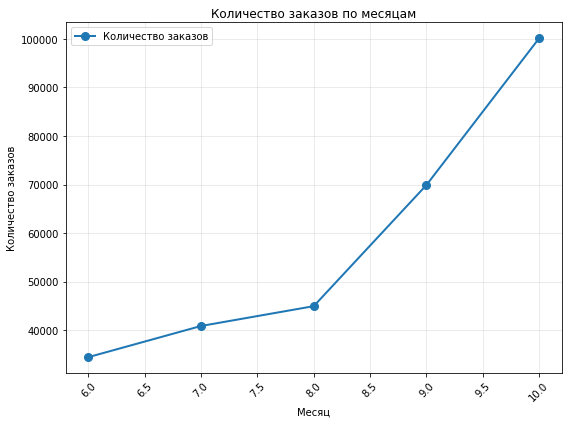

In [78]:
# Визуализируем
plt.figure(figsize=(8, 6))
plt.plot(orders_by_month['month'], orders_by_month['orders_count'], 
         marker='o', linewidth=2, markersize=8, label='Количество заказов')  # добавляем метку

plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)  
plt.tight_layout()  # автоматическая подгонка элементов
plt.legend()  
plt.show()

In [79]:
# Для осеннего и летнего периодов сравним распределение заказов в зависимости от типа мероприятия
# Фильтруем данные по сезонам, используя столбец season
summer_data = merged_df[merged_df['season'] == 'лето']
autumn_data = merged_df[merged_df['season'] == 'осень'] 

In [80]:
# Определим долю заказов зависимости от сезона
summer_event_shares = summer_data['event_type_main'].value_counts(normalize=True)
summer_event_shares

концерты    0.428297
другое      0.270045
театр       0.201086
стендап     0.053199
спорт       0.025020
выставки    0.020058
ёлки        0.002294
Name: event_type_main, dtype: float64

In [81]:
autumn_event_shares = autumn_data['event_type_main'].value_counts(normalize=True)
autumn_event_shares

концерты    0.374727
театр       0.253404
другое      0.195325
спорт       0.111024
стендап     0.041127
выставки    0.014329
ёлки        0.010064
Name: event_type_main, dtype: float64

<Figure size 864x432 with 0 Axes>

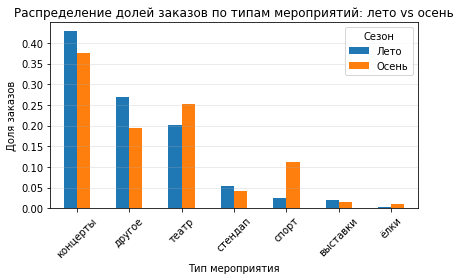

In [82]:
# Объединяем данные для визуализации
event_shares = pd.concat([summer_event_shares, autumn_event_shares], axis=1)
event_shares.columns = ['Лето', 'Осень']  # задаём понятные названия столбцов

# Строим группированную столбчатую диаграмму
plt.figure(figsize=(12, 6))
event_shares.plot(kind='bar')

plt.title('Распределение долей заказов по типам мероприятий: лето vs осень')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов')
plt.xticks(rotation=45)  
plt.legend(title='Сезон') 
plt.grid(axis='y', alpha=0.3)  
plt.tight_layout()  # автоматическая подгонка элементов
plt.show()

In [83]:
# Определим долю заказов по категории типа устройства
summer_device_shares = summer_data['device_type_canonical'].value_counts(normalize=True)
autumn_device_shares = autumn_data['device_type_canonical'].value_counts(normalize=True)

<Figure size 864x432 with 0 Axes>

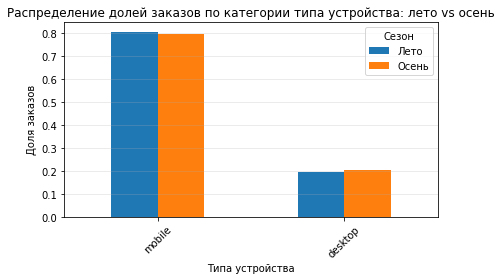

In [84]:
# Объединяем данные для визуализации
event_shares = pd.concat([summer_device_shares, autumn_device_shares], axis=1)
event_shares.columns = ['Лето', 'Осень']  # задаём понятные названия столбцов

# Строим группированную столбчатую диаграмму
plt.figure(figsize=(12, 6))
event_shares.plot(kind='bar')

plt.title('Распределение долей заказов по категории типа устройства: лето vs осень')
plt.xlabel('Типа устройства')
plt.ylabel('Доля заказов')
plt.xticks(rotation=45)  
plt.legend(title='Сезон') 
plt.grid(axis='y', alpha=0.3)  
plt.tight_layout()  # автоматическая подгонка элементов
plt.show()

In [85]:
# Определим долю заказов по категории возрастного рейтинга
summer_age_shares = summer_data['age_limit'].value_counts(normalize=True)
autumn_age_shares = autumn_data['age_limit'].value_counts(normalize=True)

<Figure size 864x432 with 0 Axes>

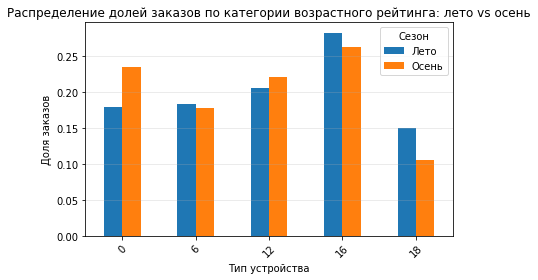

In [86]:
# Объединяем данные для визуализации
event_shares = pd.concat([summer_age_shares, autumn_age_shares], axis=1)
event_shares.columns = ['Лето', 'Осень']  # задаём понятные названия столбцов

# Строим группированную столбчатую диаграмму
plt.figure(figsize=(12, 6))
event_shares.plot(kind='bar')

plt.title('Распределение долей заказов по категории возрастного рейтинга: лето vs осень')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов')
plt.xticks(rotation=45)  
plt.legend(title='Сезон') 
plt.grid(axis='y', alpha=0.3)  
plt.tight_layout()  # автоматическая подгонка элементов
plt.show()

In [87]:
# Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью
# Группируем по сезону и типу мероприятия — считаем среднюю выручку с билета
season_revenue = merged_df.groupby(['event_type_main', 'season'])['revenue_rub'].mean().unstack()
season_revenue

season,лето,осень
event_type_main,,
выставки,42.675935,46.520586
другое,48.230727,46.833008
концерты,228.305914,155.082624
спорт,31.827177,33.355172
стендап,128.371184,143.589682
театр,115.687687,99.383675
ёлки,156.003768,149.998682


In [88]:
# Считаем относительное изменение осенней выручки по сравнению с летней (в %)
season_revenue['change_rev'] = (season_revenue['осень'] - season_revenue['лето']) / season_revenue['лето'] * 100
season_revenue['change_rev']

event_type_main
выставки     9.008945
другое      -2.897986
концерты   -32.072446
спорт        4.800911
стендап     11.855073
театр      -14.093127
ёлки        -3.849321
Name: change_rev, dtype: float64

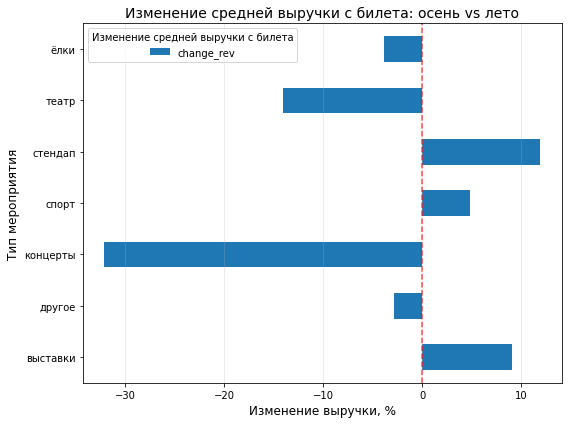

In [89]:
# Визуализируем
plt.figure(figsize=(8, 6))
season_revenue['change_rev'].plot(kind='barh')
plt.title('Изменение средней выручки с билета: осень vs лето', fontsize=14)
plt.xlabel('Изменение выручки, %', fontsize=12)
plt.ylabel('Тип мероприятия', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)  
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.legend(title='Изменение средней выручки с билета') 
plt.show()

Из графиков мы видим, что количество заказов билетов с июня по октябрь росло (34641 - 40886 шт.). В летние месяцы наблюдается стабильный рост, а осенью - резкий подъем с сентября по октябрь (69906 - 100125 шт.). Доля заказов с наступлением осени сократилась: у концертов (с 42,8 % до 37.5 % ), стендапа (с 5.3 % до 4.1 %), выставок (с 2 % до 1.4 %). У остальных типов мероприятий доля увеличилась: театры (с 20.1 % до 25.3 %), спорт (с 2.5 % до 11.1 %), елки (с 0.2 % до 1 %).

Средняя стоимость билета осенью по сравнению с летом выставок практически не изменилась (стала - 46.52, была - 42.7), концертом сократилась (стала - 155.08 , была - 228.4), спорт - увеличилась (стала - 33.35, была - 31.83), стендап -  увеличилась (стала - 143.58, была - 128.37), театр - увеличилась (стала - 99.38, была - 115.67), елки - увеличилась (стала - 150 , была - 156). 
Таким образом с наступлением осени наиболее востребованы у покупателей оказались категории: театр, спорт и елки. Средняя стоимость возрасла на спорт, стендап, театр и елки.

### 3.2. Осенняя активность пользователей


In [90]:
# Проанализируйте динамику изменений по дням 
# Выбираем осенние месяцы
autumn_data = merged_df[merged_df['season'] == 'осень'] 

# Создаём сводную таблицу по дням и сезону
daily_activity = autumn_data.groupby(['created_dt_msk', 'season']).agg(
    total_orders=('order_id', 'count'),  # общее число заказов
    total_revenue=('revenue_rub', 'sum'),  # общая выручка
    unique_users=('user_id', 'nunique'),  # DAU — уникальные пользователи
    total_tickets=('tickets_count', 'sum')   # общее число билетов
).reset_index()
daily_activity

,created_dt_msk,season,total_orders,total_revenue,unique_users,total_tickets
0,2024-09-01,осень,1348,151030.587508,569,3816
1,2024-09-02,осень,1390,154944.429472,580,3743
2,2024-09-03,осень,5124,238214.152694,783,15345
3,2024-09-04,осень,1781,184110.124373,687,4839
4,2024-09-05,осень,1956,213974.992914,745,5251
...,...,...,...,...,...,...
56,2024-10-27,осень,2865,304479.567946,1039,7933
57,2024-10-28,осень,2857,287854.879371,988,7999
58,2024-10-29,осень,2885,307254.561628,1005,8131
59,2024-10-30,осень,2959,324010.392342,1049,8204


In [91]:
daily_activity.head()

,created_dt_msk,season,total_orders,total_revenue,unique_users,total_tickets
0,2024-09-01,осень,1348,151030.587508,569,3816
1,2024-09-02,осень,1390,154944.429472,580,3743
2,2024-09-03,осень,5124,238214.152694,783,15345
3,2024-09-04,осень,1781,184110.124373,687,4839
4,2024-09-05,осень,1956,213974.992914,745,5251


In [92]:
# Рассчитываем метрики среднего числа заказов на человека и среднюю стоимость билета
daily_activity['orders_per_user'] = daily_activity['total_orders'] / daily_activity['unique_users']
daily_activity['avg_ticket_price'] = daily_activity['total_revenue'] / daily_activity['total_tickets']
print(daily_activity['orders_per_user'], daily_activity['avg_ticket_price'])

0     2.369069
1     2.396552
2     6.544061
3     2.592431
4     2.625503
        ...   
56    2.757459
57    2.891700
58    2.870647
59    2.820782
60    4.666927
Name: orders_per_user, Length: 61, dtype: float64 0     39.578246
1     41.395787
2     15.523894
3     38.047143
4      40.74938
        ...    
56     38.38139
57    35.986358
58    37.788041
59    39.494197
60    31.824128
Name: avg_ticket_price, Length: 61, dtype: Float64


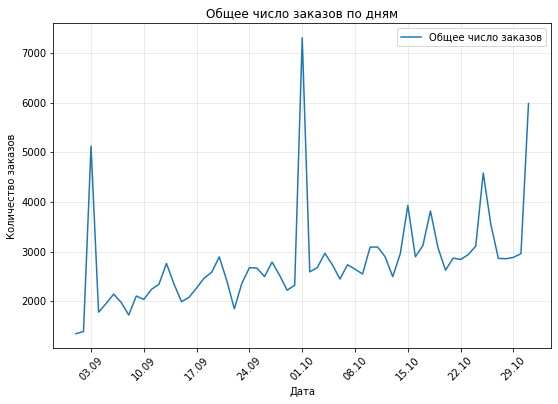

In [93]:
# Визуализируем метрики
plt.figure(figsize=(8, 6))

# Общее число заказов
plt.plot(daily_activity['created_dt_msk'], daily_activity['total_orders'],label='Общее число заказов')
plt.title('Общее число заказов по дням')
plt.ylabel('Количество заказов')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)  
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # метки каждую неделю
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))    # формат: день.месяц
plt.show()

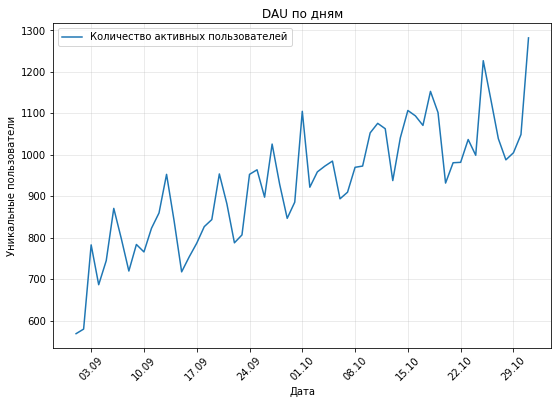

In [94]:
# Визуализируем метрики
plt.figure(figsize=(8, 6))

# DAU
plt.plot(daily_activity['created_dt_msk'], daily_activity['unique_users'],label='Количество активных пользователей')
plt.title('DAU по дням')
plt.ylabel('Уникальные пользователи')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)  
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # метки каждую неделю
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))    # формат: день.месяц
plt.show()

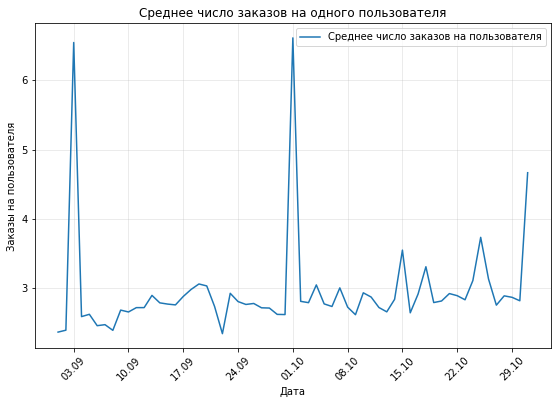

In [95]:
# Визуализируем метрики
plt.figure(figsize=(8, 6))

# Среднее число заказов на пользователя
plt.plot(daily_activity['created_dt_msk'], daily_activity['orders_per_user'],label='Среднее число заказов на пользователя')
plt.title('Среднее число заказов на одного пользователя')
plt.ylabel('Заказы на пользователя')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)  
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # метки каждую неделю
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))    # формат: день.месяц
plt.show()

<Figure size 576x432 with 0 Axes>

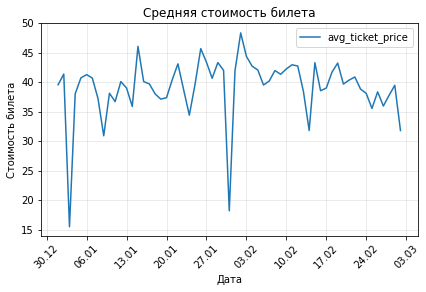

In [96]:
# Визуализируем метрики
plt.figure(figsize=(8, 6))

# Средняя стоимость одного билета
daily_activity['created_dt_msk'] = pd.to_datetime(daily_activity['created_dt_msk']).dt.date
daily_activity[['created_dt_msk','avg_ticket_price']].plot()
plt.title('Средняя стоимость билета')
plt.ylabel('Стоимость билета')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)  
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # метки каждую неделю
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))    # формат: день.месяц
plt.show()

In [97]:
daily_activity

,created_dt_msk,season,total_orders,total_revenue,unique_users,total_tickets,orders_per_user,avg_ticket_price
0,2024-09-01,осень,1348,151030.587508,569,3816,2.369069,39.578246
1,2024-09-02,осень,1390,154944.429472,580,3743,2.396552,41.395787
2,2024-09-03,осень,5124,238214.152694,783,15345,6.544061,15.523894
3,2024-09-04,осень,1781,184110.124373,687,4839,2.592431,38.047143
4,2024-09-05,осень,1956,213974.992914,745,5251,2.625503,40.74938
...,...,...,...,...,...,...,...,...
56,2024-10-27,осень,2865,304479.567946,1039,7933,2.757459,38.38139
57,2024-10-28,осень,2857,287854.879371,988,7999,2.891700,35.986358
58,2024-10-29,осень,2885,307254.561628,1005,8131,2.870647,37.788041
59,2024-10-30,осень,2959,324010.392342,1049,8204,2.820782,39.494197


In [98]:
# Изучим недельную цикличность
# Фильтруем данные за осень 2024, используя столбец season
fall_2024 = daily_activity[daily_activity['season'] == 'осень']

# Преобразуем дату в правильный формат
fall_2024['created_dt_msk'] = pd.to_datetime(fall_2024['created_dt_msk'])

# Добавляем день недели и признак будни и выходные
fall_2024['day_of_week'] = fall_2024['created_dt_msk'].dt.dayofweek
fall_2024['is_weekend'] = fall_2024['day_of_week'].isin([5, 6]).astype(int)  # 5 — суббота, 6 — воскресенье

In [99]:
# Создаём столбец с текстовыми названиями дней для наглядности
fall_2024['day_name'] = fall_2024['day_of_week'].map({
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'
}) # Заменяем числовые обозначения дней недели на их сокращённые текстовые названия

# Группируем по дню недели и статусу «будни и выходные», считаем среднюю активность
daily_activity = fall_2024.groupby(['day_name', 'is_weekend'])['unique_users'].mean()

# Выделяем активность в будни (is_weekend == 0) и в выходные (is_weekend == 1)
weekday_activity = daily_activity.loc[:, 0]  # Будни
weekend_activity = daily_activity.loc[:, 1]  # Выходные

print("Активность в будни:")
print(weekday_activity)
print("\nАктивность в выходные:")
print(weekend_activity)

Активность в будни:
day_name
Вт     939.777778
Пн     859.000000
Пт    1029.125000
Ср     930.666667
Чт     967.888889
Name: unique_users, dtype: float64

Активность в выходные:
day_name
Вс    827.222222
Сб    966.750000
Name: unique_users, dtype: float64


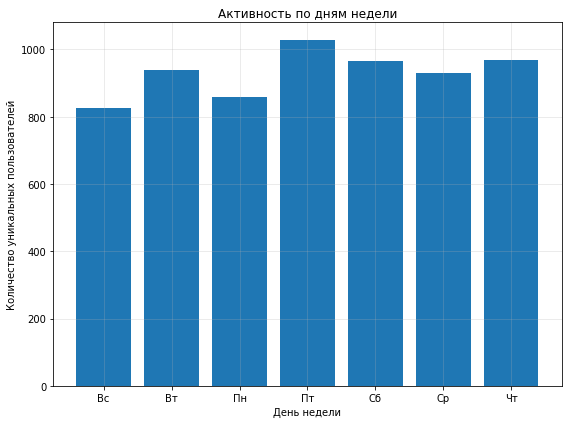

In [100]:
# Визуализируем активность пользователей в зависимости от дня недели
daily_activity_reset = daily_activity.reset_index()

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(daily_activity_reset['day_name'], daily_activity_reset['unique_users'])
ax1.set_title('Активность по дням недели')
ax1.set_ylabel('Количество уникальных пользователей')
ax1.set_xlabel('День недели')  
ax1.grid(True, alpha=0.3)     
plt.tight_layout()
plt.show()

In [101]:
# Визуализируем активность пользователей в выходные и будни

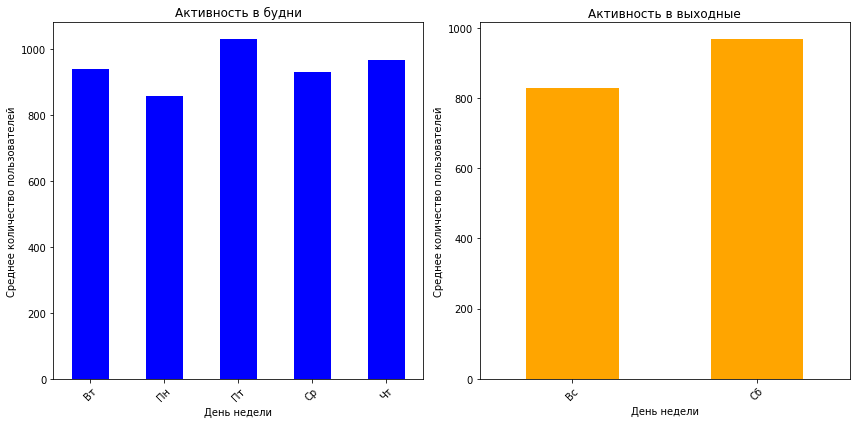

In [102]:
weekday_activity = daily_activity.loc[:, 0]  # Будни
weekend_activity = daily_activity.loc[:, 1]   # Выходные


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
weekday_activity.plot(kind='bar', color='blue')
plt.title('Активность в будни')
plt.xlabel('День недели')
plt.ylabel('Среднее количество пользователей')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
weekend_activity.plot(kind='bar', color='orange')
plt.title('Активность в выходные')
plt.xlabel('День недели')
plt.ylabel('Среднее количество пользователей')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Общее число заказов в осенний период увеличилось с 1348 до 5983 штук, то есть в 4.4 раза. Динамика числа заказов наблюдается сильная, максимальное количество достигало 7305 штук 01.10.2024г., минимальное - 1348 штук 01.09.2024г., среднее количество - 2787 штук.
Количество пользователей в сентябре - октябре увеличилось с 569 до 1282 человек, то есть в 2.3 раза. Динамика числа активных пользователей  аналогично сильная. Среднее число заказов увеличилось с 2.37 до 4.67 шт. практически в 2 раза. Максимлаьное - 6.61 шт, минимальное - 2.35 шт.
Средняя стоимость билета изменилась с 39.58 руб. до 31.82 руб., сократилась в 0.8 раз. Все показатели, кроме средней стоимости билета, увеличились.
Недельная цикличность: активность пользователей сервисом стабильно высокая, во вторник (939 чел.) и четверг (967 чел.) наблюдается стогнация, а в пятницу (1029 чел.) с приближением выходных - резкий рост , с субботы (967 чел.) по воскресенье плавное сокращение (827 чел.). Ближе к выходным и в выходные дни люди проявляют большую активность и приобретают билеты. Таким образом, в осенний период пользователи больше начинают интересоваться и проявлять активност в сервисе. 

###  3.3. Популярные события и партнёры

In [103]:
# Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов
unique_events_by_region = merged_df.groupby('region_name')['event_id'].nunique()
total_orders_by_region = merged_df.groupby('region_name').size()                                  

In [104]:
# Рассчитаем долю проводимых мероприятий от их общего числа
total_unique_events = unique_events_by_region.sum()
proportion_of_events = unique_events_by_region / total_unique_events
proportion_of_events

region_name
белоярская_область      0.002543
берестовский_округ      0.001740
берёзовская_область     0.007405
боровлянский_край       0.004327
верховинская_область    0.000357
                          ...   
шанырский_регион        0.001249
широковская_область     0.055000
яблоневская_область     0.023865
ягодиновская_область    0.005353
яснопольский_округ      0.000223
Name: event_id, Length: 81, dtype: float64

In [105]:
# Рассчитаем долю заказов в регионе от их общего числа
total_orders = total_orders_by_region.sum()
proportion_of_orders = total_orders_by_region / total_orders
proportion_of_orders

region_name
белоярская_область      0.000685
берестовский_округ      0.001361
берёзовская_область     0.004416
боровлянский_край       0.005928
верховинская_область    0.000172
                          ...   
шанырский_регион        0.009924
широковская_область     0.056656
яблоневская_область     0.021274
ягодиновская_область    0.003596
яснопольский_округ      0.000072
Length: 81, dtype: float64

In [106]:
event_type_main = merged_df.groupby('region_name')['event_type_main'].unique()

# Создаём сводную таблицу с добавлением столбца с наименованиями
results = pd.DataFrame({
    'unique_events': unique_events_by_region,
    'total_orders': total_orders_by_region,
    'proportion_events': proportion_of_events,
    'proportion_orders': proportion_of_orders,
    'event_type_main': event_type_main
}).sort_values('unique_events', ascending=False)
results

,unique_events,total_orders,proportion_events,proportion_orders,event_type_main
region_name,,,,,
каменевский_регион,5981,90995,0.266795,0.313440,"[театр, выставки, другое, концерты, стендап, с..."
североярская_область,3811,43914,0.169997,0.151265,"[другое, стендап, выставки, театр, концерты, с..."
широковская_область,1233,16448,0.055000,0.056656,"[концерты, ёлки, стендап, театр, другое, выста..."
светополянский_округ,1075,7600,0.047953,0.026179,"[ёлки, концерты, выставки, театр, другое, спор..."
речиновская_область,702,6288,0.031314,0.021660,"[другое, театр, концерты, стендап, спорт, выст..."
...,...,...,...,...,...
теплоозёрский_округ,2,7,0.000089,0.000024,[концерты]
сосноводолинская_область,2,10,0.000089,0.000034,"[концерты, другое]"
лесноярский_край,2,19,0.000089,0.000065,"[другое, театр]"


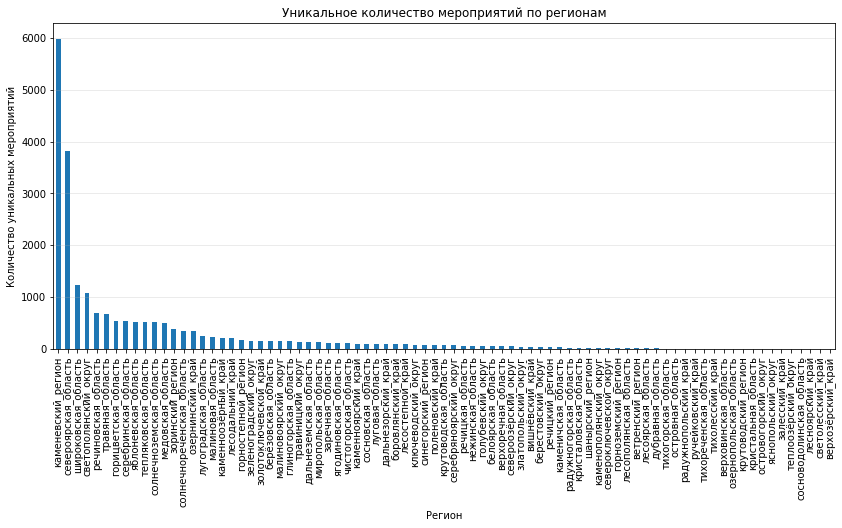

In [107]:
# Сортируем по убыванию 
unique_events_by_region_sorted = unique_events_by_region.sort_values(ascending=False)

plt.figure(figsize=(14, 6)) 
unique_events_by_region_sorted.plot(kind='bar') 
plt.title('Уникальное количество мероприятий по регионам')
plt.xlabel('Регион')
plt.ylabel('Количество уникальных мероприятий')
plt.grid(axis='y', alpha=0.3)  
plt.show() 

Разнообразие мероприятий наиболее высоко в следующих регионах/областях: Каменевский регион (26,7 %), Североярская област (17 %), Широковская область (5.5 %), Светополянский округ (4.8 %) и Речиновская область (3.1 %).

In [108]:
# Для каждого партнёра посчитаем общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов 
partner_metrics = merged_df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),      # Уникальные мероприятия
    total_orders=('order_id', 'size'),           # Общее число заказов
    total_revenue=('revenue_rub', 'sum')            # Суммарная выручка
).reset_index() 
partner_metrics

,service_name,unique_events,total_orders,total_revenue
0,Crazy ticket!,257,790,8.791469e+04
1,Show_ticket,295,2200,3.624967e+05
2,Билет по телефону,20,85,1.385537e+04
3,Билеты без проблем,4249,63347,5.506843e+06
4,Билеты в интернете,1,4,1.017242e+02
5,Билеты в руки,3538,40317,2.561819e+06
6,Быстробилет,255,2001,3.039296e+05
7,Быстрый кассир,20,381,7.810986e+04
8,Весь в билетах,867,16845,3.458123e+06
9,Восьмёрка,144,1118,1.317667e+05


In [109]:
total_unique_events = partner_metrics['unique_events'].sum()
total_orders = partner_metrics['total_orders'].sum()
total_revenue = partner_metrics['total_revenue'].sum()

# Доли показателей каждого партнёра от общих итогов
partner_metrics['proportion_events'] = partner_metrics['unique_events'] / total_unique_events  # Доля мероприятий
partner_metrics['proportion_orders'] = partner_metrics['total_orders'] / total_orders         # Доля заказов
partner_metrics['proportion_revenue'] = partner_metrics['total_revenue'] / total_revenue     # Доля выручки

In [110]:
# Сортируем таблицу по убыванию числа уникальных мероприятий 
partner_metrics_sorted = partner_metrics.sort_values(
    by='unique_events', ascending=False
)
partner_metrics_sorted

,service_name,unique_events,total_orders,total_revenue,proportion_events,proportion_orders,proportion_revenue
21,Лови билет!,4882,41102,3.390549e+06,0.199607,0.141579,9.711575e-02
3,Билеты без проблем,4249,63347,5.506843e+06,0.173726,0.218204,1.577329e-01
5,Билеты в руки,3538,40317,2.561819e+06,0.144656,0.138875,7.337836e-02
25,Облачко,2348,26640,4.142058e+06,0.096001,0.091764,1.186413e-01
22,Лучшие билеты,1762,17757,5.424187e+05,0.072042,0.061165,1.553654e-02
24,Мой билет,1305,34802,8.040650e+06,0.053357,0.119878,2.303089e-01
30,Тебе билет!,1062,5225,5.927728e+05,0.043421,0.017998,1.697884e-02
26,Прачечная,1027,10272,9.383003e+05,0.041990,0.035383,2.687580e-02
8,Весь в билетах,867,16845,3.458123e+06,0.035449,0.058024,9.905126e-02
35,Яблоко,716,5039,7.678600e+05,0.029275,0.017357,2.199387e-02


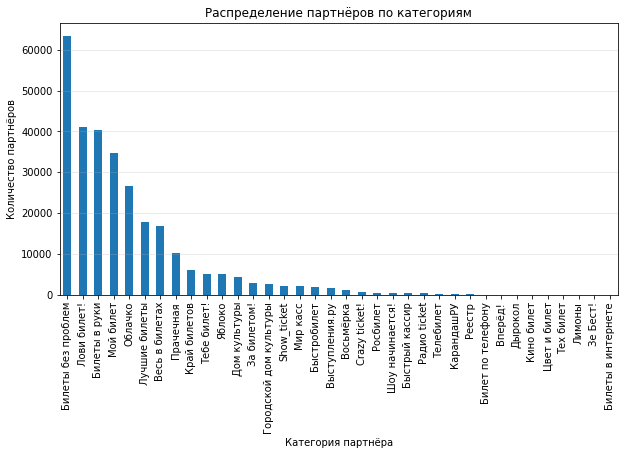

In [111]:
# Группируем и считаем количество записей по каждой категории
partner_categories = merged_df.groupby('service_name').size()
# Сортируем по убыванию
partner_categories = partner_categories.sort_values(ascending=False)

# Строим график
plt.figure(figsize=(10, 5))
partner_categories.plot(kind='bar')
plt.title('Распределение партнёров по категориям')
plt.xlabel('Категория партнёра')
plt.ylabel('Количество партнёров')
plt.grid(axis='y', alpha=0.3)
plt.show()

Наиболее активные партнеры:'Билеты без проблем' 63537 шт., 'Лови билет!' 41104 шт., 'Билеты в руки' 40338 шт, 'Мой билет' 34806, 'Облачко' 26640 шт.

## Статистический анализ данных

### Подготовка к тесту первой гипотезы

Цель: Провести оценку результатов A/B-теста. Проверить гипотезу, которая предполагают большую активность пользователей мобильных устройств.

Задачи: 

1. Рассчитать параметры теста.
2. Оценить корректность его проведения.
3. Проанализировать результаты эксперимента.

Проверим гипотезу, предполагающую большую активность пользователей мобильных устройств:
Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

В качестве целевой метрики возьмем среднее количество заказов на одного пользователя.

In [112]:
# Фильтруем данные за осень
fall_orders = merged_df[merged_df['season'] == 'осень']

# Группируем по пользователям, считаем число заказов для каждого
user_order_counts = fall_orders.groupby('user_id').size()

# Среднее количество заказов на пользователя за осень
avg_orders_per_user_fall = user_order_counts.mean()

print(f"Среднее количество заказов на пользователя осенью: {avg_orders_per_user_fall:.2f}")

Среднее количество заказов на пользователя осенью: 10.72


###  Мониторинг А/В-теста первой гипотезы

In [113]:
# Проверка распределения по группам, определим количество уникальных значений в столбце device_type_canonical
group_distribution = fall_orders['device_type_canonical'].value_counts()

display("Распределение по группам:")
display(group_distribution)

display("Доли пользователей в группах:")
display((group_distribution / group_distribution.sum() * 100).round(2))

'Распределение по группам:'

mobile     135390
desktop     34619
Name: device_type_canonical, dtype: int64

'Доли пользователей в группах:'

mobile     79.64
desktop    20.36
Name: device_type_canonical, dtype: float64

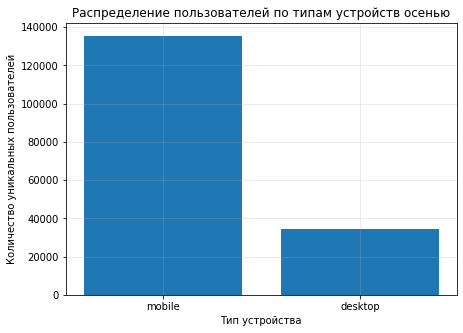

In [114]:
group_distribution = fall_orders['device_type_canonical'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(group_distribution.index, group_distribution.values) 
plt.title('Распределение пользователей по типам устройств осенью')  
plt.ylabel('Количество уникальных пользователей')
plt.xlabel('Тип устройства')  
plt.grid(True, alpha=0.3) 
plt.show()

In [115]:
# Рассчитаем количество пользователей, которые встречаются одновременно в группах mobile и desktop
# Получаем списки  пользователей для каждой группы

users_A = fall_orders[fall_orders['device_type_canonical'] == 'mobile']['user_id'].tolist()
users_B = fall_orders[fall_orders['device_type_canonical'] == 'desktop']['user_id'].tolist()

# Преобразуем в множества и находим пересечение
common_users = set(users_A) & set(users_B)
number_of_common_users = len(common_users)

print(f"Количество пользователей, встречающихся одновременно в группах mobile и desktop: {number_of_common_users}")

Количество пользователей, встречающихся одновременно в группах mobile и desktop: 3271


In [116]:
# Рассмотрим распределние по категориям в группах mobile и desktop

In [117]:
fall_orders

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_name,venue_address,data,nominal,curs,cdx,revenue_rub,one_ticket_revenue_rub,month,season
14,4222372,0beb8fc0c0a9ce1,2024-10-21,2024-10-21 14:14:26,169230,нет,16,rub,mobile,1521.939941,...,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-10-21,100,19.7884,kzt,301.167563,75.291891,10,осень
15,5244622,0e6fa925c5f346f,2024-09-11,2024-09-11 13:34:03,169230,нет,16,rub,desktop,1141.449951,...,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-09-11,100,19.0258,kzt,217.169985,72.389995,9,осень
16,5244651,0e6fa925c5f346f,2024-09-11,2024-09-11 13:35:58,169230,нет,16,rub,desktop,1141.449951,...,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-09-11,100,19.0258,kzt,217.169985,72.389995,9,осень
19,4173884,1a7e020ee0b4418,2024-10-11,2024-10-11 18:14:13,169230,нет,16,rub,desktop,1141.449951,...,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-10-11,100,19.8829,kzt,226.953352,75.651117,10,осень
21,6074399,26068df7451bdb0,2024-10-23,2024-10-23 13:46:01,169230,нет,16,rub,mobile,760.969971,...,"сценический_центр_""деталь""_групп","алл._машиностроителей,_д._19_стр._6",2024-10-23,100,20.0531,kzt,152.598069,76.299035,10,осень
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290305,5718946,ff684621b134cc4,2024-10-03,2024-10-03 12:01:53,358061,нет,18,rub,mobile,241.000000,...,"студия_видеомонтажа_""парадигма""_лимитед","пр._серова,_д._100_стр._32",2024-10-03,100,19.6841,kzt,47.438681,47.438681,10,осень
290306,7375078,ff684621b134cc4,2024-10-06,2024-10-06 12:32:09,12820,нет,18,rub,desktop,279.820007,...,"архив_""туман""_лимитед","ш._водопроводное,_д._87_стр._572",2024-10-06,100,19.6475,kzt,54.977636,18.325879,10,осень
290307,343390,ff684621b134cc4,2024-10-31,2024-10-31 12:27:42,357588,нет,6,rub,mobile,427.059998,...,"санкт-петербургский_дом_культуры_""сказка""_лтд","алл._макарова,_д._5/2",2024-10-31,100,19.7383,kzt,84.294383,21.073596,10,осень
290308,7378935,ff6bf53a0207b52,2024-10-02,2024-10-02 20:58:31,300765,нет,6,rub,mobile,224.880005,...,"творческое_объединение_""ветер""_инкорпорэйтед","пр._тупиковый,_д._9_стр._8",2024-10-02,100,19.4015,kzt,43.630094,14.543365,10,осень


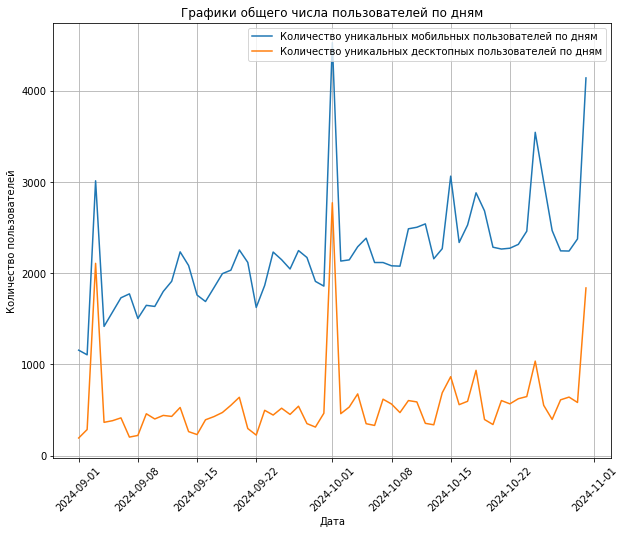

In [118]:
# Группируем данные по дате и типу устройства, считаем количество уникальных пользователей
mobile_data = fall_orders[fall_orders['device_type_canonical'] == 'mobile'].groupby('created_dt_msk').size()
desktop_data = fall_orders[fall_orders['device_type_canonical'] == 'desktop'].groupby('created_dt_msk').size()

# Строим графики
plt.figure(figsize=(10, 8))
plt.plot(mobile_data.index, mobile_data, label='Количество уникальных мобильных пользователей по дням')
plt.plot(desktop_data.index, desktop_data, label='Количество уникальных десктопных пользователей по дням')
plt.xticks(rotation=45)
plt.title('Графики общего числа пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.legend()
plt.show()

На основе проведённого анализа, мы видим, что распределние количества уникальных пользователей в группах mobile и desktop равномерно. Выборки групп являются независимыми, поскольку общие значения  были удалены, что является одним из условий проведения A/B-теста. 
Вышеизложенное говорит о том, что они сопоставимы между собой и сохраняется равномерное распределние пользователей по типам устройств. Таким образом, исходя из полученных данных, мы можем предположить, что весьма корректно проходит A/B-тест.

### Проверка результатов A/B-теста первой гипотезы

Получение результатов теста и подсчёт основной метрики

In [119]:
# Мобильные устройства
metric_a = fall_orders[fall_orders['device_type_canonical'] == 'mobile']
# Десктопные устройства
metric_b = fall_orders[fall_orders['device_type_canonical'] == 'desktop']

In [120]:
# Для каждого пользователя считаем кол-во заказов
avg_orders_per_user_mobile = metric_a.groupby('user_id')['order_id'].nunique()
avg_orders_per_user_desktop = metric_b.groupby('user_id')['order_id'].nunique()

# Делаем проверку
print(avg_orders_per_user_mobile.mean(), avg_orders_per_user_desktop.mean())

9.512400758799972 7.059339314845024


### Формулировка нулевой и альтернативной гипотез первая

В качестве основной метрики мы взяли среднее количество заказов на одного пользователя.

Нулевая гипотеза: среднее количество заказов на одного пользователя мобильного приложения и среднее количество заказов со стационарных устройств не отличается. H0: μA = μB


Альтернативная гипотеза: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств. H1: μA > μB

Для проведения A/B-теста мы можем использовать тест Стьдента, поскольку есть две группы для сравнения, данные количественные (среднее количество заказов на одного пользователя), переменные независимы (наблюдения в одной группе не связаны с наблюдениями в другой) и данные приблизительно нормально распределены.

In [121]:

# Уровень значимости
alpha = 0.05



stat_ttest, p_value_ttest = ttest_ind(
    avg_orders_per_user_mobile,
    avg_orders_per_user_desktop,
    alternative='greater' # если гипотеза: среднее в mobile > среднего в desktop
)


# Выводим средние 
avg_orders_mobile = avg_orders_per_user_mobile.mean()
avg_orders_desktop = avg_orders_per_user_desktop.mean()

print(f"Среднее количество заказов (mobile): {avg_orders_mobile:.2f}")
print(f"Среднее количество заказов (desktop): {avg_orders_desktop:.2f}")

# Интерпретация результата
if p_value_ttest > alpha:
    print(f'p-value теста Стьюдента = {round(p_value_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение!')
    print("Средние количества заказов в группах 'mobile' и 'desktop' не различаются статистически значимо.")
else:
    print(f'p-value теста Стьюдента = {round(p_value_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения!')
    print("Существует статистически значимая разница между средними количествами заказов в группах 'mobile' и 'desktop'.")

Среднее количество заказов (mobile): 9.51
Среднее количество заказов (desktop): 7.06
p-value теста Стьюдента = 0.01
Нулевая гипотеза не находит подтверждения!
Существует статистически значимая разница между средними количествами заказов в группах 'mobile' и 'desktop'.


Таким образом, в ходе исследования мы взяли в качестве основной метрики среднее количество заказов на одного пользователя.


Нулевая гипотеза: среднее количество заказов на одного пользователя мобильного приложения и среднее количество заказов со стационарных устройств не отличается. H0: μA = μB

Альтернативная гипотеза: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств. H1: μA > μB


Исходя из расчетов выше,среднее количество заказов на одного пользователя (mobile): 9.51, количество заказов на одного пользователя (mobile): 7.06 , p-value теста Стьюдента = 0.01.(нулевая гипотеза о том, что среднее количество заказов на одного пользователя мобильного приложения и среднее количество заказов со стационарных устройств не отличается, не находит подтверждения). Поэтому мы можем принять альтернативную гипотизу о том, что существует статистически значимая разница между средними количествами заказов в группах 'mobile' и 'desktop', а именно среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств. H1: μA > μB. Это доказывает большую активность пользователей мобильных устройств. 

### Подготовка к тесту второй гипотезы

Цель: Провести оценку результатов A/B-теста. Проверить гипотезу, которая предполагают большую активность пользователей мобильных устройств.

Задачи: 

1. Рассчитать параметры теста.
2. Оценить корректность его проведения.
3. Проанализировать результаты эксперимента.

Проверим гипотезу, предполагающую большую активность пользователей мобильных устройств:
среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

В качестве целевой метрики возьмем среднее время между заказами пользователей.

In [122]:
# Фильтруем данные за осень
fall_orders = merged_df[merged_df['season'] == 'осень']

# Считаем среднее время между заказами — используем готовый столбец с интервалами
avg_time_between_fall = fall_orders['days_since_prev'].mean()

print(f"Среднее время между заказами осенью: {avg_time_between_fall:.2f} дней")

Среднее время между заказами осенью: 3.63 дней


###  Мониторинг А/В-теста второй гипотезы

In [123]:
# Проверка распределения по группам, определим количество уникальных значений в столбце days_since_prev
group_distribution = fall_orders['days_since_prev'].value_counts(dropna=False).sort_index()

display("Распределение интервалов между заказами (в днях):")
display(group_distribution)

display("Доли заказов в каждом интервале (в %):")
display((group_distribution / group_distribution.sum() * 100).astype(float).round(2))

'Распределение интервалов между заказами (в днях):'

0      113335
1       16897
2        5501
3        3417
4        2454
        ...  
145         3
146         6
147         3
148         3
NaN      8409
Name: days_since_prev, Length: 150, dtype: Int64

'Доли заказов в каждом интервале (в %):'

0      66.66
1       9.94
2       3.24
3       2.01
4       1.44
       ...  
145     0.00
146     0.00
147     0.00
148     0.00
NaN     4.95
Name: days_since_prev, Length: 150, dtype: float64

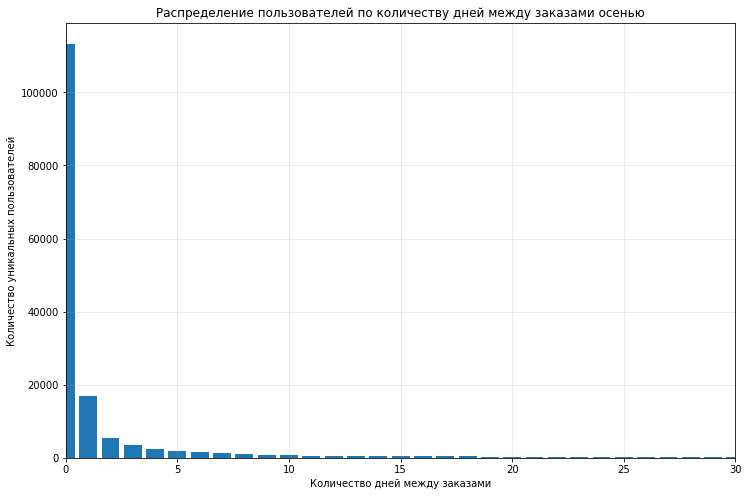

In [124]:
group_distribution = fall_orders['days_since_prev'].value_counts(dropna=False).sort_index()
# Фильтруем значения, исключая NaT
filtered_index = group_distribution.index[~group_distribution.index.isna()]
filtered_values = group_distribution[filtered_index]

plt.figure(figsize=(12, 8))
plt.bar(filtered_index, filtered_values)
plt.title('Распределение пользователей по количеству дней между заказами осенью')
plt.ylabel('Количество уникальных пользователей')
plt.xlabel('Количество дней между заказами')
plt.xlim(0, 30)
plt.grid(True, alpha=0.3)
plt.show()

In [125]:
# Рассчитаем количество пользователей, которые встречаются одновременно в группах mobile и desktop
# Получаем списки  пользователей для каждой группы

users_A = fall_orders[fall_orders['device_type_canonical'] == 'mobile']['user_id'].tolist()
users_B = fall_orders[fall_orders['device_type_canonical'] == 'desktop']['user_id'].tolist()

# Преобразуем в множества и находим пересечение
common_users = set(users_A) & set(users_B)
number_of_common_users = len(common_users)

print(f"Количество пользователей, встречающихся одновременно в группах mobile и desktop: {number_of_common_users}")

Количество пользователей, встречающихся одновременно в группах mobile и desktop: 3271


In [126]:
# Рассмотрим распределние по категориям в группах mobile и desktop

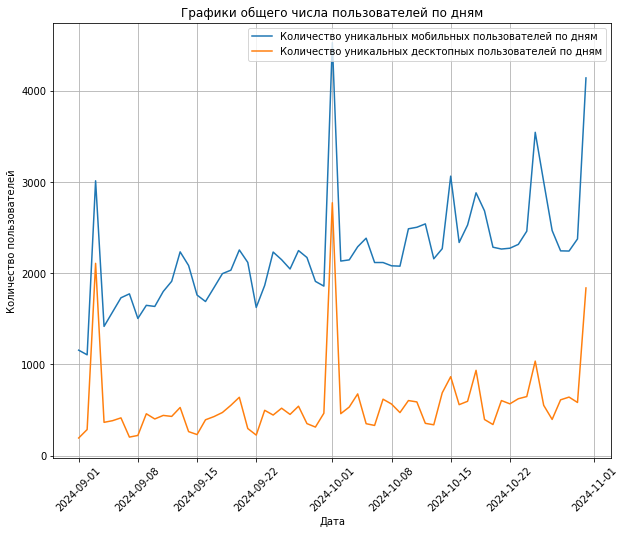

In [127]:
# Группируем данные по дате и типу устройства, считаем количество уникальных пользователей
mobile_data = fall_orders[fall_orders['device_type_canonical'] == 'mobile'].groupby('created_dt_msk').size()
desktop_data = fall_orders[fall_orders['device_type_canonical'] == 'desktop'].groupby('created_dt_msk').size()

# Строим графики
plt.figure(figsize=(10, 8))
plt.plot(mobile_data.index, mobile_data, label='Количество уникальных мобильных пользователей по дням')
plt.plot(desktop_data.index, desktop_data, label='Количество уникальных десктопных пользователей по дням')
plt.xticks(rotation=45)
plt.title('Графики общего числа пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.legend()
plt.show()

На основе проведённого анализа, мы видим, что распределние количества уникальных пользователей в группах mobile и desktop равномерно. Выборки групп являются независимыми, поскольку общие значения  были удалены, что является одним из условий проведения A/B-теста. 
Вышеизложенное говорит о том, что они сопоставимы между собой и сохраняется равномерное распределние пользователей по типам устройств. Таким образом, исходя из полученных данных, мы можем предположить, что весьма корректно проходит A/B-тест.

### Проверка результатов A/B-теста второй гипотезы

Получение результатов теста и подсчёт основной метрики

In [128]:
# Мобильные устройства
metric_a = fall_orders[fall_orders['device_type_canonical'] == 'mobile']
# Десктопные устройства
metric_b = fall_orders[fall_orders['device_type_canonical'] == 'desktop']

In [129]:
# Для каждого пользователя считаем кол-во дней между заказами пользователей
avg_orders_per_user_mobile = metric_a.groupby('user_id')['days_since_prev'].nunique()
avg_orders_per_user_desktop = metric_b.groupby('user_id')['days_since_prev'].nunique()

# Делаем проверку
print(avg_orders_per_user_mobile.mean(), avg_orders_per_user_desktop.mean())

2.0604932199817325 1.6788336052202284


### Формулировка нулевой и альтернативной гипотез вторая 

В качестве основной метрики мы взяли среднее время между заказами пользователей.

Нулевая гипотеза: среднее время между заказами пользователей мобильного приложения и среднее время между заказами пользователей со стационарных устройств не отличается. H0: μA = μB

Альтернативная гипотеза: среднее время между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств. H1: μA > μB

Для проведения A/B-теста мы можем использовать тест Стьдента, поскольку есть две группы для сравнения, данные количественные (среднее время между заказами), переменные независимы (наблюдения в одной группе не связаны с наблюдениями в другой) и данные приблизительно нормально распределены.

In [130]:
# Уровень значимости
alpha = 0.05



stat_ttest, p_value_ttest = ttest_ind(
    avg_orders_per_user_mobile,
    avg_orders_per_user_desktop,
    alternative='greater' # если гипотеза: среднее в mobile > среднего в desktop
)



# Выводим средние 
avg_orders_mobile = avg_orders_per_user_mobile.mean()
avg_orders_desktop = avg_orders_per_user_desktop.mean()

print(f"Среднее количество дней между заказами (mobile): {avg_orders_mobile:.2f}")
print(f"Среднее количество дней между заказами (desktop): {avg_orders_desktop:.2f}")

# Интерпретация результата
if p_value_ttest > alpha:
    print(f'p-value теста Стьюдента = {round(p_value_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение!')
    print("Среднее количество дней между заказами в группах 'mobile' и 'desktop' не различаются статистически значимо.")
else:
    print(f'p-value теста Стьюдента = {round(p_value_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения!')
    print("Существует статистически значимая разница между средним количеством дней между заказами в группах 'mobile' и 'desktop'.")

Среднее количество дней между заказами (mobile): 2.06
Среднее количество дней между заказами (desktop): 1.68
p-value теста Стьюдента = 0.0
Нулевая гипотеза не находит подтверждения!
Существует статистически значимая разница между средним количеством дней между заказами в группах 'mobile' и 'desktop'.


Таким образом, в ходе исследования мы взяли в качестве основной метрики среднее время между заказами пользователей.


Нулевая гипотеза: среднее время между заказами пользователей мобильного приложения и среднее время между заказами пользователей со стационарных устройств не отличается. H0: μA = μB

Альтернативная гипотеза: среднее время между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств. H1: μA > μB


Исходя из расчетов выше, среднее количество дней между заказами (mobile): 2.06, среднее количество дней между заказами (desktop): 1.68, p-value теста Стьюдента = 0.0.(нулевая гипотеза о том, что среднее количество дней между заказами в группах 'mobile' и 'desktop' не различаются статистически значимо, не находит подтверждения). Поэтому мы можем принять альтернативную гипотизу о том, что Существует статистически значимая разница между средним количеством дней между заказами в группах 'mobile' и 'desktop', а именно среднее время между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств. H1: μA > μB. Это доказывает большую активность пользователей мобильных устройств.

## Общий вывод и рекомендации

Целью данного проекта было — выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.


Задачи:

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Статистический анализ данных.
4. Общий вывод и рекомендации.
 
 
Датасет final_tickets_orders_df.csv содержит 14 столбцов и 290848 строк.
После первичного анализа данных делаем следующие выводы:
Названия столбцов мы привели к одному виду (snake case). Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64, float64, object. Названия столбцов отражают содержимое данных и прописаны в удобном для работы виде. Пропуски содержатся только в столбце days_since_prev. Тип данных полей created_dt_msk и created_ts_msk заменили на соответсвующий тип даты.

Датасет final_tickets_events_df.csv содержит 11 столбцов и 22427 строк.
Аналогично названия столбцов мы привели к одному виду (snake case). Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64 и object. Названия столбцов отражают содержимое данных и прописаны в удобном для работы виде. Пропуски отсутствуют.

Датасет final_tickets_tenge_df.csv содержит 4 столбца и 357 строк.
Названия столбцов мы привели к одному виду (snake case). Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64, float64, object. Названия столбцов отражают содержимое данных и прописаны в удобном для работы виде. Пропуски отсутствуют. Тип данных поля data не соотвествует верному, поменяли его.

 
После обработки данных из  после обработки данных из 290 611 строк датасета у нас осталось 290 311 (0.1% потерь). Были изучены пропуски в данных ,они наблюдались в столбце days_since_prev (7.5%). Процент пропусков в поле небольшой, поэтому его просто можно оставить. Так же произвели нормализацию данных в столбцах: cinema_circuit, event_name, event_type_description,event_type_main, region_name, city_name, venue_name, venue_address; данные проверили на явные и неявные дубликаты, и удалили. По данным стат показателей и диаграммы размаха, были обнаружены и удалены выбросы в столбцах: revenue, tickets_count. Изменили тип данных created_dt_msk, created_ts_msk,data, понизили разрядность - days_since_prev, tickets_count, revenue, total, а так же создали столбцы revenue_rub (выручка с заказа в рублях), one_ticket_revenue_rub (выручка с продажи одного билета на мероприятие в рублях), month (месяц оформления заказа), season (столбец с информацией о сезонности).

В анализе распределения заказов по сегментам и их сезонных изменениям наблюдпем:
Рамер выручки от мероприятий с июня по август был стабилен:выставки  (0.3 % - 0.06 %), спорт (0.2 % - 1 %), стендап (2.6 % - 7 %), театр (11 % - 19.3 %) и елки (0.2 % - 0.4 %), с августа по октябрь начал увеличиваться и составлял у выставок (0.06 - 0.08 %), спорта (0.2 % - 3.3 %),театра (19.3 % - 24.3) и елок (0.4 % - 2 %), а у стендапа (7 % - 5.5 %) - незначительно сократился.
Размер выручки концертов с июня по июль сокращался (80 % - 55.4%), с июля по сентябрь происходит постепенный рост (58.5% - 56.2%). С наступлением осени интерес к разлчным мероприятиям пользователей увеличился и ,соотвественно, роста выручка от посещения мероприятий, наибольшую выручку приносят концерты.

Количество заказов билетов с июня по октябрь росло (34641 шт. - 40886 шт.). В летние месяцы наблюдается стабильный рост, а осенью - резкий подъем с сентября по октябрь (69906 шт. - 100125 шт.). Данные тенденции можно объяснить тем, что люди начали возвращаться с отпусков и дач, погода не располагала для прогулок и они выброли досуг в виде посещения различных развлекательных мероприятий.

Средняя стоимость билета осенью по сравнению с летом выставок практически не изменилась (стала - 46.52, была - 42.7), концертом сократилась (стала - 155.08 , была - 228.4), спорт - увеличилась (стала - 33.35, была - 31.83), стендап -  увеличилась (стала - 143.58, была - 128.37), театр - увеличилась (стала - 99.38, была - 115.67), елки - увеличилась (стала - 150 , была - 156). 
С наступлением осени наиболее востребованы у покупателей оказались категории: театр, спорт и елки. Средняя стоимость возрасла на спорт, стендап, театр и елки.

Недельная цикличность: активность пользователей сервисом стабильно высокая, во вторник (939 чел.) и четверг (967 чел.) наблюдается стогнация, а в пятницу (1029 чел.) с приближением выходных - резкий рост , с субботы (967 чел.) по воскресенье плавное сокращение (827 чел.). Ближе к выходным и в выходные дни люди проявляют большую активность и приобретают билеты, предпочетаю именно культурный отдых.

Исследовав две гипотезы:


* Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
* Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

 Исследовав и проверив гипотизу о том, что существует статистически значимая разница между средними количествами заказов в группах 'mobile' и 'desktop', а именно среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств. H1: μA > μB, мы доказали, что именно пользователей мобильных устройств проявляют большую активность.

 Изучив вторую гипотезу гипотизу о том, что существует статистически значимая разница между средним количеством дней между заказами в группах 'mobile' и 'desktop', а именно среднее время между заказами пользователей мобильного приложения выше по сравнению с пользователями стационарных устройств. H1: μA > μB, аналогичным образом, доказали большую активность пользователей мобильных устройств.
 Таким образом, мы выявили разницу в поведении пользователей с мобильных и стациональных устройст.